# Import Required Libraries

Import libraries such as `json`, `pandas`, `matplotlib.pyplot`, and `seaborn` for data manipulation and visualization.


In [1]:
# Import required libraries
import json  # For loading JSON files
import pandas as pd  # For data manipulation
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns  # For enhanced visualizations

# Configure seaborn for better aesthetics
sns.set_theme(style="whitegrid")

# Load JSON Files

Load the JSON files from different frameworks into Python dictionaries for further processing.


In [4]:
# Define file paths for the JSON files
files = {
    "Alibi-Detect": "results/results_alibidetect_20250325112836.json",
    "Evidently": "results/results_evidently_20250321143343.json",
    "Frouros": "results/results_frouros_20250325113341.json",
    "NannyML": "results/results_nannyml_20250321103604.json",
    "River": "results/results_river_20250325155340.json",
}


# Function to load JSON files into Python dictionaries
def load_json(file_path):
    """Load a JSON file and return its content."""
    with open(file_path, "r") as f:
        return json.load(f)


# Load JSON files into Python dictionaries
data = {name: load_json(path) for name, path in files.items()}

# Print confirmation of successful loading
print("JSON files loaded successfully.")

JSON files loaded successfully.


# Extract and Normalize Data

Extract relevant data (runtime, memory, CPU time) from each JSON file and normalize it into a consistent format using Pandas DataFrames.


In [5]:
# Define a function to extract and normalize data from a JSON structure
def extract_normalized_data(data, framework_name):
    """
    Extracts relevant data (runtime, memory, CPU time) from the JSON structure
    and normalizes it into a consistent format.
    """
    records = []
    for framework_results in data:
        for result in framework_results:
            records.append(
                {
                    "Framework": framework_name,
                    "Method": result["method"],
                    "Runtime (avg)": result["runtime"]["avg"],
                    "Runtime (max)": result["runtime"]["max"],
                    "Runtime (min)": result["runtime"]["min"],
                    "CPU Time (avg)": result["cputime"]["avg"],
                    "CPU Time (max)": result["cputime"]["max"],
                    "CPU Time (min)": result["cputime"]["min"],
                    "Memory (avg)": result["memory"]["avg"],
                    "Memory (max)": result["memory"]["max"],
                    "Memory (min)": result["memory"]["min"],
                }
            )
    return pd.DataFrame(records)


# Extract and normalize data for each framework
data_frames = {
    name: extract_normalized_data(framework_data, name) 
    for name, framework_data in data.items()
}  # fmt: skip


# Combine all data into a single DataFrame
combined_df = pd.concat(
    [df for df in data_frames.values()],
    ignore_index=True,
)

# Display the first few rows of the combined DataFrame for verification
combined_df.head()

,Framework,Method,Runtime (avg),Runtime (max),Runtime (min),CPU Time (avg),CPU Time (max),CPU Time (min),Memory (avg),Memory (max),Memory (min)
0,Alibi-Detect,Chi-square Test,0.050697,0.051836,0.049204,0.049389,0.050020,0.048363,1332.742188,1332.742188,1332.742188
1,Alibi-Detect,Kolmogorov-Smirnov Test,0.014441,0.016635,0.012953,0.012877,0.013031,0.012798,1332.875000,1332.875000,1332.875000
2,Alibi-Detect,Cramér-von Mises Test,0.015656,0.017359,0.014664,0.014812,0.014892,0.014770,1333.035156,1333.035156,1333.035156
3,Alibi-Detect,Mixed-Type Tabular Data,0.013941,0.014563,0.013545,0.013124,0.013210,0.013070,1333.046875,1333.046875,1333.046875
4,Evidently,Kolmogorov-Smirnov Test,0.121274,0.151694,0.099139,0.095469,0.096653,0.094758,513.170573,513.171875,513.167969


# Compare Runtime Across Frameworks

Create bar plots or line plots to compare the average runtime of methods across different frameworks.


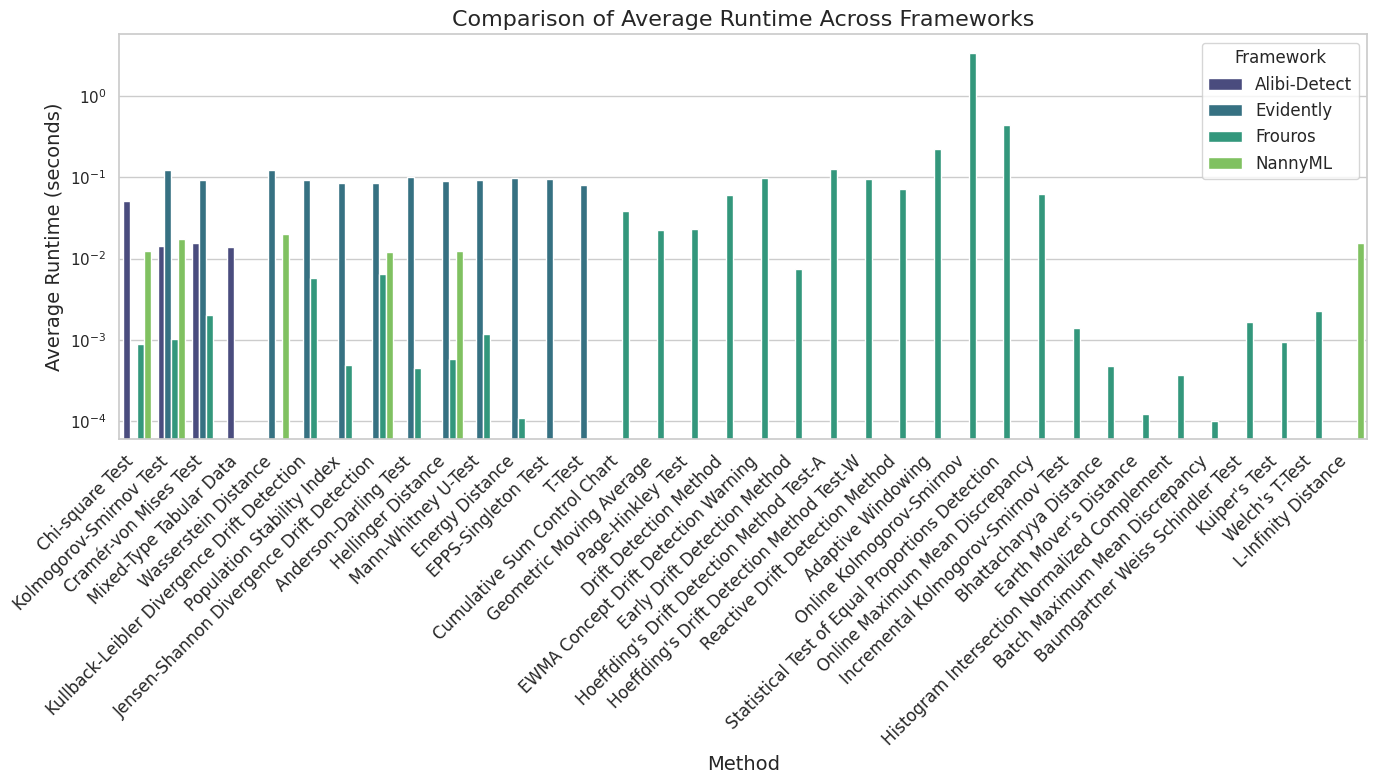

In [ ]:
# Compare Runtime Across Frameworks

# Create a bar plot to compare the average runtime of methods across frameworks
plt.figure(figsize=(14, 8))
sns.barplot(data=combined_df, x="Method", y="Runtime (avg)", hue="Framework", palette="viridis")

# Customize the plot
plt.title("Comparison of Average Runtime Across Frameworks", fontsize=16)
plt.ylabel("Average Runtime (seconds)", fontsize=14)
plt.yscale("log")
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.legend(title="Framework", fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

# Compare Memory Usage Across Frameworks

Generate plots to compare the average memory usage of methods across frameworks.


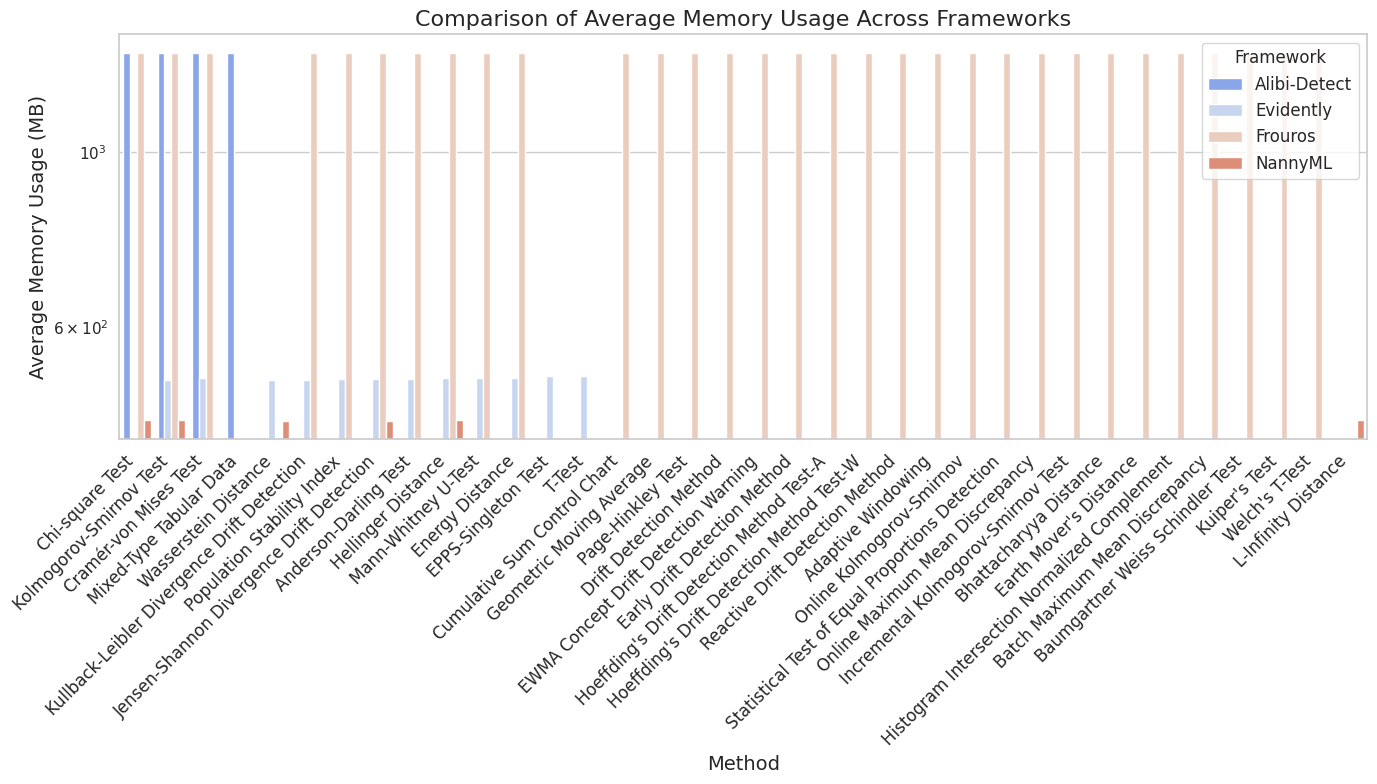

In [ ]:
# Compare Memory Usage Across Frameworks

# Create a bar plot to compare the average memory usage of methods across frameworks
plt.figure(figsize=(14, 8))
sns.barplot(data=combined_df, x="Method", y="Memory (avg)", hue="Framework", palette="coolwarm")

# Customize the plot
plt.title("Comparison of Average Memory Usage Across Frameworks", fontsize=16)
plt.xlabel("Method", fontsize=14)
plt.ylabel("Average Memory Usage (MB)", fontsize=14)
plt.yscale("log")
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.legend(title="Framework", fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

# Compare CPU Time Across Frameworks

Visualize the average CPU time of methods across frameworks using appropriate plots.


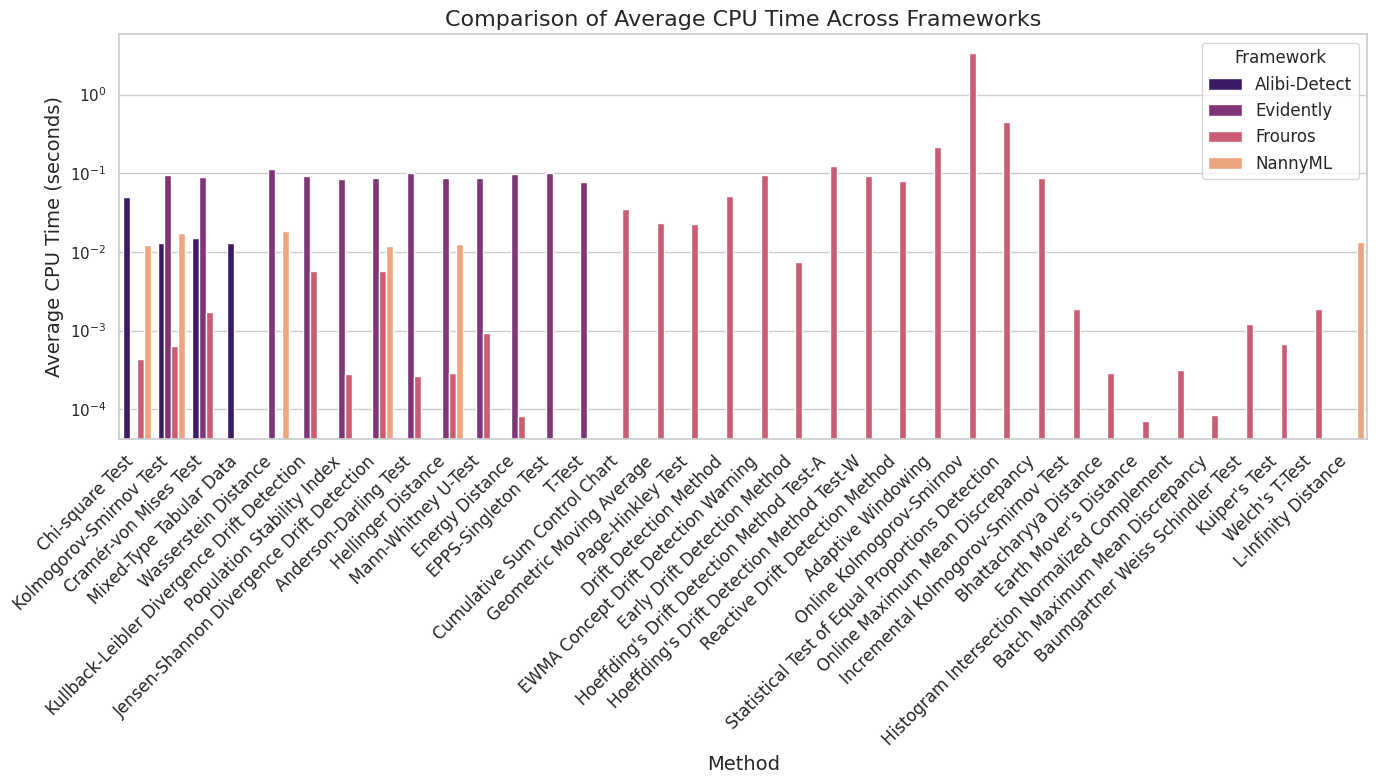

In [ ]:
# Compare CPU Time Across Frameworks

# Create a bar plot to compare the average CPU time of methods across frameworks
plt.figure(figsize=(14, 8))
sns.barplot(data=combined_df, x="Method", y="CPU Time (avg)", hue="Framework", palette="magma")

# Customize the plot
plt.title("Comparison of Average CPU Time Across Frameworks", fontsize=16)
plt.xlabel("Method", fontsize=14)
plt.ylabel("Average CPU Time (seconds)", fontsize=14)
plt.yscale("log")
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.legend(title="Framework", fontsize=13)
plt.tight_layout()

# Show the plot
plt.show()